# Mini-Project 4: Machine Learning | Customer Churn Prediction

**Load the data**

In this project, we will be working with Spaceship Telcom Customer Churn Dataset from Kaggle. The data can be found here:

https://www.kaggle.com/datasets/mosapabdelghany/telcom-customer-churn-dataset

“Which customers are likely to churn?”

In [ ]:
# Import libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from  pathlib import Path

In [2]:
csv_path = Path(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_ML_Churn\Telco_Cusomer_Churn.csv")
print(csv_path)

C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_ML_Churn\Telco_Cusomer_Churn.csv


In [3]:
df = pd.read_csv(csv_path)

Data Description
- **CustomerID**: A unique ID that identifies each customer.
- **Gender**: The customer’s gender: Male, Female.
- **Senior Citizen**: Indicates if the customer is 65 or older: Yes, No.
- **Partner**: Indicates if the customer has a partner: Yes, No.
- **Dependents**: Indicates if the customer lives with any dependents: Yes, No.
- **Tenure in Months**: Total number of months the customer has been with the company.
- **Phone Service**: Indicates if the customer subscribes to home phone service: Yes, No.
- **Multiple Lines**: Indicates if the customer subscribes to multiple phone lines: Yes, No.
- **Internet Service**: Type of internet service: No, DSL, Fiber Optic, Cable.
- **Online Security**: Indicates subscription to online security service: Yes, No.
- **Online Backup**: Indicates subscription to online backup service: Yes, No.
- **Device Protection**: Indicates subscription to device protection plan: Yes, No.
- **Tech Support**: Indicates subscription to technical support service: Yes, No.
- **Streaming TV**: Indicates if the customer streams TV content: Yes, No.
- **Streaming Movies**: Indicates if the customer streams movies: Yes, No.
- **Contract**: Customer contract type: Month-to-Month, One Year, Two Year.
- **Paperless Billing**: Indicates if paperless billing is enabled: Yes, No.
- **Payment Method**: Payment type: Bank Withdrawal, Credit Card, Mailed Check.
- **Monthly Charge**: Customer’s monthly charge amount.
- **Total Charges**: Customer’s total charges to date.
- **Churn**: Yes = customer left the company, No = customer stayed.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.describe().T

# TotalCharges → can be very large >> Use Standard Scaler which is less sensitive to outliers.

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
# Check the data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Convers "TotalCharges" into numeric format
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtypes

dtype('float64')

In [10]:
# Rename the Customer ID column
df.rename(columns={"customerID": "customerId"}, inplace=True)

In [11]:
# Tronsform the column names to lower case
import re

# columns
df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in df.columns]

# string values
# df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [12]:
# Check for missing values
df.isnull().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_t_v         0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [13]:
# Dropping all missing values
df = df.dropna()

In [14]:
df.head(3)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [15]:
df["customer_id"].nunique()

7032

Visualization customer behavior

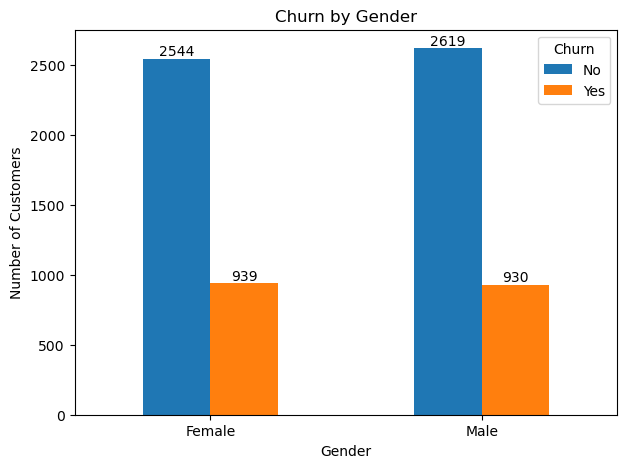

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Crosstab
churn_gender = pd.crosstab(df["gender"], df["churn"])

# Plot
ax = churn_gender.plot(kind="bar", figsize=(7,5))

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.legend(title="Churn")

plt.show()

In [17]:
gender_counts = (
    df["gender"]
      .value_counts(normalize=True) # Normalize return proportions (percentages) instead of raw counts.
      .mul(100) # mul put in 100 instead 0.1
      .round(2)
)
gender_counts

gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64

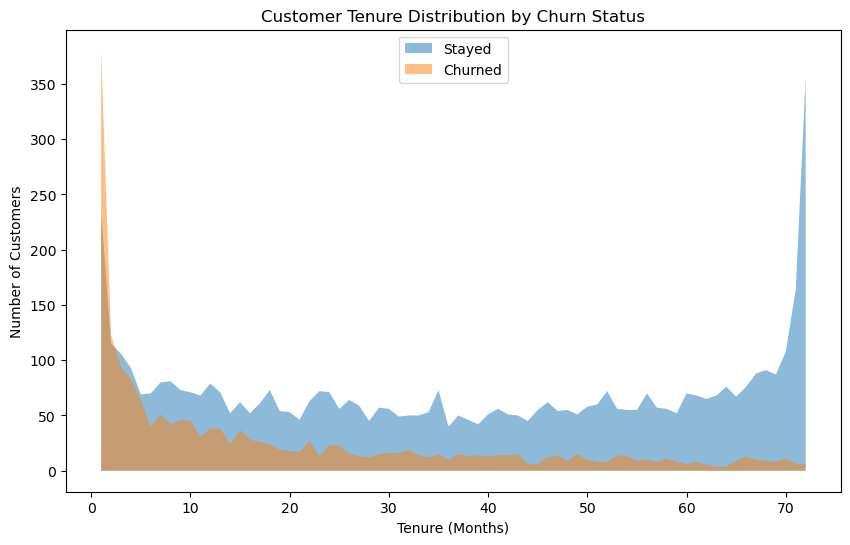

In [18]:
import matplotlib.pyplot as plt

# Count customers per tenure value
tenure_churn_no = df[df["churn"] == "No"]["tenure"].value_counts().sort_index()
tenure_churn_yes = df[df["churn"] == "Yes"]["tenure"].value_counts().sort_index()

# Align indexes (important)
all_index = sorted(set(tenure_churn_no.index).union(set(tenure_churn_yes.index)))

tenure_churn_no = tenure_churn_no.reindex(all_index, fill_value=0)
tenure_churn_yes = tenure_churn_yes.reindex(all_index, fill_value=0)

# Plot area chart
plt.figure(figsize=(10,6))

plt.fill_between(all_index, tenure_churn_no, alpha=0.5, label="Stayed")
plt.fill_between(all_index, tenure_churn_yes, alpha=0.5, label="Churned")

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.legend()
plt.show()

C:\Users\glint\AppData\Local\Temp\ipykernel_20840\2741728711.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


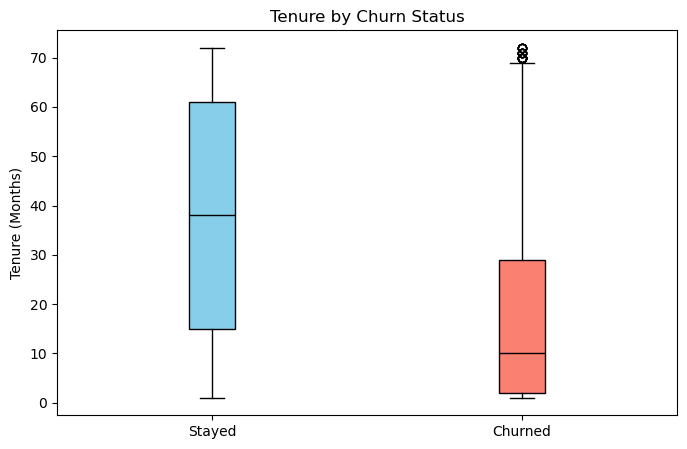

In [19]:
import matplotlib.pyplot as plt

# Split data
churn_yes = df[df["churn"] == "Yes"]["tenure"]
churn_no = df[df["churn"] == "No"]["tenure"]

plt.figure(figsize=(8,5))

box = plt.boxplot(
    [churn_no, churn_yes],
    labels=["Stayed", "Churned"],
    patch_artist=True
)

# Add colors
colors = ["skyblue", "salmon"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Style whiskers and caps (optional but nicer)
for element in ["whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

plt.title("Tenure by Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

C:\Users\glint\AppData\Local\Temp\ipykernel_20840\262112177.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


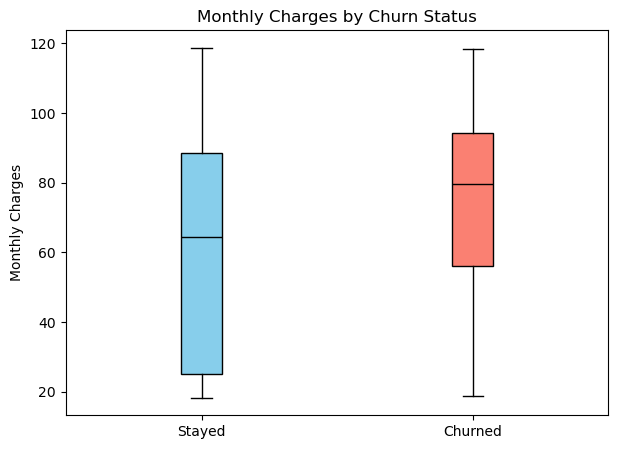

In [20]:
import matplotlib.pyplot as plt

# Split data
charges_yes = df[df["churn"] == "Yes"]["monthly_charges"]
charges_no = df[df["churn"] == "No"]["monthly_charges"]

plt.figure(figsize=(7,5))

# Create colored boxplot
box = plt.boxplot(
    [charges_no, charges_yes],
    labels=["Stayed", "Churned"],
    patch_artist=True
)

# Colors
colors = ["skyblue", "salmon"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Style lines
for element in ["whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

# Titles
plt.title("Monthly Charges by Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

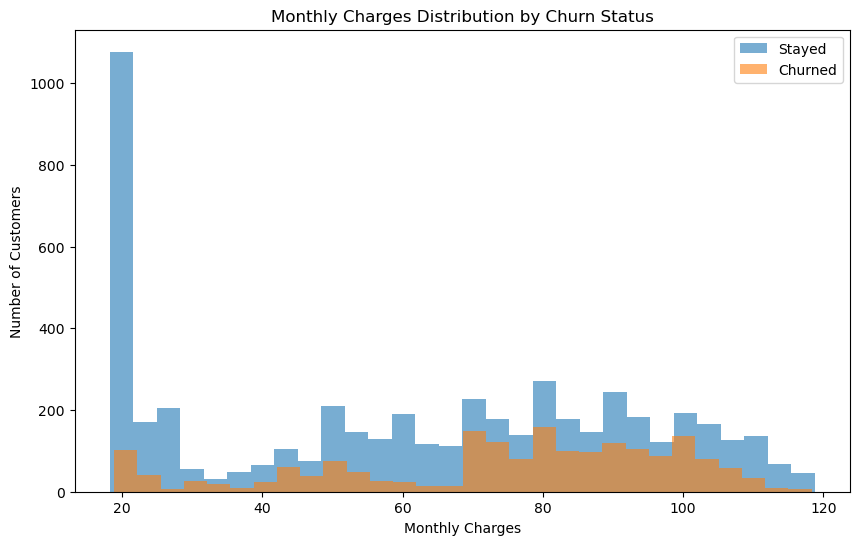

In [21]:
import matplotlib.pyplot as plt

charges_yes = df[df["churn"] == "Yes"]["monthly_charges"]
charges_no = df[df["churn"] == "No"]["monthly_charges"]

plt.figure(figsize=(10,6))

plt.hist(charges_no, bins=30, alpha=0.6, label="Stayed")
plt.hist(charges_yes, bins=30, alpha=0.6, label="Churned")

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.legend()
plt.show()

C:\Users\glint\AppData\Local\Temp\ipykernel_20840\2177060561.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


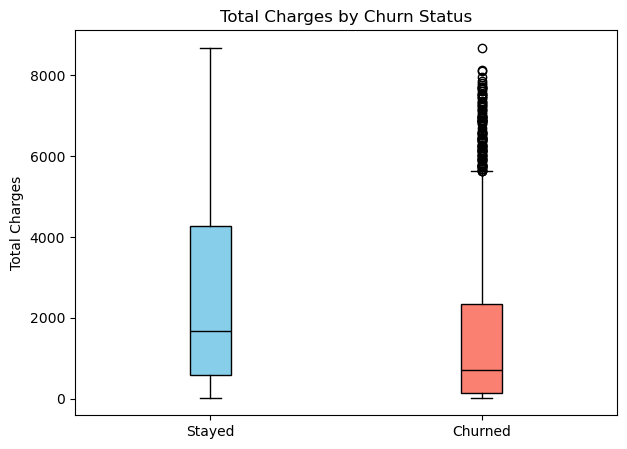

In [22]:
import matplotlib.pyplot as plt

# Split data
charges_yes = df[df["churn"] == "Yes"]["total_charges"]
charges_no = df[df["churn"] == "No"]["total_charges"]

plt.figure(figsize=(7,5))

# Create colored boxplot
box = plt.boxplot(
    [charges_no, charges_yes],
    labels=["Stayed", "Churned"],
    patch_artist=True
)

# Colors
colors = ["skyblue", "salmon"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Style lines
for element in ["whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

# Titles
plt.title("Total Charges by Churn Status")
plt.ylabel("Total Charges")

plt.show()

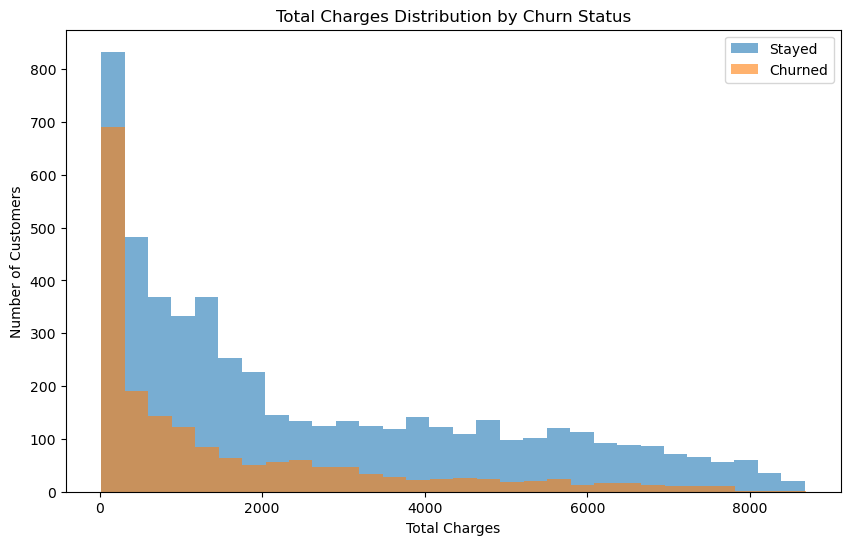

In [23]:
total_charges_yes = df[df["churn"] == "Yes"]["total_charges"]
total_charges_no = df[df["churn"] == "No"]["total_charges"]

plt.figure(figsize=(10,6))

plt.hist(charges_no, bins=30, alpha=0.6, label="Stayed")
plt.hist(charges_yes, bins=30, alpha=0.6, label="Churned")

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.legend()
plt.show()

In [24]:
df.shape

(7032, 21)

In [25]:
#Check the duplicates
df.duplicated().sum()

np.int64(0)

In [26]:
df_clean = df.drop(columns=["customer_id"])

In [51]:
#Save the ds to .csv:
df_clean.to_csv('customer_churn_clean.csv', index=False)